# Baseball Pitch Identification - Supervised Learning
## SIADS 696 Milestone II
**Author:** Ian MacKinnon  
**Dataset:** MLB Statcast 2023-2025 via pybaseball  
**Goal:** Train a Random Forest classifier to recreate official MLB pitch labels from ball-flight features, then evaluate which pitch categories are easiest or hardest to distinguish.

## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SEED = 42
np.random.seed(SEED)

print("All imports successful")

All imports successful


## 2. Load Data

In [ ]:
DATA_YEARS = [2023, 2024, 2025]
DATA_DIR = 'data'
SOURCE_REPO = 'https://github.com/sachinmurthy14641/Milestone2_baseball_project'

season_frames = []
for year in DATA_YEARS:
    path = f'{DATA_DIR}/statcast_{year}_raw.parquet'
    season_df = pd.read_parquet(path)
    season_df['season'] = year
    season_frames.append(season_df)
    print(f"{year} dataset shape: {season_df.shape}")

df_raw = pd.concat(season_frames, ignore_index=True)

print(f"\nCombined dataset shape: {df_raw.shape}")
print(f"\nRows by season:")
print(df_raw['season'].value_counts().sort_index())
print(f"\nPitch type distribution:")
print(df_raw['pitch_type'].value_counts())

2023 dataset shape: (720684, 119)
2024 dataset shape: (731904, 119)
2025 dataset shape: (711897, 119)

Combined dataset shape: (2164485, 119)

Rows by season:
2023    720684
2024    731904
2025    711897
Name: season, dtype: int64

Pitch type distribution:
FF    686241
SI    335129
SL    322428
CH    224348
FC    169540
ST    150990
CU    139142
FS     61954
KC     39463
SV     10361
FA      2648
EP      2120
FO      1683
KN      1386
CS       531
SC       236
PO       155
UN        14
Name: pitch_type, dtype: int64


## 3. Feature Selection & Filtering
Use the same ball-flight features as the unsupervised notebook. These variables describe pitch velocity, spin, movement, location, release point, and acceleration. The supervised target is the existing MLB `pitch_type` label.

In [3]:
BALL_FLIGHT_FEATURES = [
    'release_speed',       # velocity out of hand
    'effective_speed',     # perceived velocity at plate
    'release_spin_rate',   # spin rate (RPM)
    'spin_axis',           # spin axis (degrees)
    'pfx_x',               # horizontal break (inches, catcher's POV)
    'pfx_z',               # vertical break (induced, inches)
    'plate_x',             # horizontal location at plate
    'plate_z',             # vertical location at plate
    'release_pos_x',       # release point X
    'release_pos_y',       # release point Y (distance from mound)
    'release_pos_z',       # release point Z (height)
    'release_extension',   # extension toward plate
    'vx0', 'vy0', 'vz0',   # velocity components at release
    'ax', 'ay', 'az',      # acceleration components
]

PITCH_TYPE_MAP = {
    'FF': 'Four-Seam Fastball', 'SI': 'Sinker', 'FC': 'Cutter',
    'SL': 'Slider', 'CU': 'Curveball', 'CH': 'Changeup',
    'FS': 'Split-Finger', 'ST': 'Sweeper', 'KC': 'Knuckle Curve', 'SV': 'Slurve'
}

# Drop pitch types with fewer than 1000 samples to avoid tiny classes
MIN_SAMPLES = 1000
valid_types = df_raw['pitch_type'].value_counts()
valid_types = valid_types[valid_types >= MIN_SAMPLES].index.tolist()
print(f"Pitch types retained: {valid_types}")

# Drop FA (generic fastball) because it overlaps heavily with FF
valid_types = [pt for pt in valid_types if pt != 'FA']
print(f"After dropping FA: {valid_types}")

MODEL_COLS = BALL_FLIGHT_FEATURES + ['pitch_type', 'p_throws', 'season']

df = (
    df_raw
    .loc[df_raw['pitch_type'].isin(valid_types), MODEL_COLS]
    .dropna(subset=MODEL_COLS)
    .reset_index(drop=True)
)

print(f"\nRaw rows:      {len(df_raw):,}")
print(f"Filtered rows: {len(df):,}  ({len(df)/len(df_raw)*100:.1f}% retained)")
print(f"Pitch types:   {df['pitch_type'].nunique()}")

Pitch types retained: ['FF', 'SI', 'SL', 'CH', 'FC', 'ST', 'CU', 'FS', 'KC', 'SV', 'FA', 'EP', 'FO', 'KN']
After dropping FA: ['FF', 'SI', 'SL', 'CH', 'FC', 'ST', 'CU', 'FS', 'KC', 'SV', 'EP', 'FO', 'KN']

Raw rows:      2,164,485
Filtered rows: 2,134,301  (98.6% retained)
Pitch types:   13


## 4. Class Balance & Target Labels
Before modeling, inspect the label distribution. Accuracy alone can be misleading if the model performs well on frequent pitch types but struggles on smaller classes.

,pitch_type,pitch_name,count,pct_of_data
0,FF,Four-Seam Fastball,683219,32.010
1,SI,Sinker,333070,15.610
2,SL,Slider,320874,15.030
3,CH,Changeup,223393,10.470
4,FC,Cutter,168768,7.910
5,ST,Sweeper,150114,7.030
6,CU,Curveball,138568,6.490
7,FS,Split-Finger,61667,2.890
8,KC,Knuckle Curve,39320,1.840
9,SV,Slurve,10247,0.480


Pitch counts by season:


pitch_type,FF,SI,SL,CH,FC,ST,CU,FS,KC,SV,EP,FO,KN
season,,,,,,,,,,,,,
2023,229000,110273,112083,77445,56604,45031,46692,16026,14149,3039,557,766,192
2024,228887,112942,106395,73166,58851,51643,44424,22354,12559,3646,574,170,979
2025,225332,109855,102396,72782,53313,53440,47452,23287,12612,3562,951,735,137


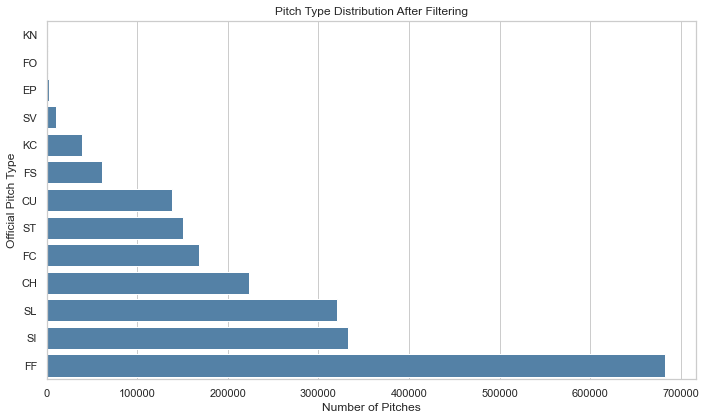

In [4]:
pitch_counts = df['pitch_type'].value_counts()
label_order = pitch_counts.index.tolist()
label_names = [f"{pt} - {PITCH_TYPE_MAP.get(pt, pt)}" for pt in label_order]

class_balance = pd.DataFrame({
    'pitch_type': pitch_counts.index,
    'pitch_name': [PITCH_TYPE_MAP.get(pt, pt) for pt in pitch_counts.index],
    'count': pitch_counts.values,
    'pct_of_data': (pitch_counts.values / len(df) * 100).round(2)
})
display(class_balance)

season_pitch_counts = pd.crosstab(df['season'], df['pitch_type']).loc[:, label_order]
print("Pitch counts by season:")
display(season_pitch_counts)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=class_balance.sort_values('count', ascending=True),
    x='count', y='pitch_type', color='steelblue', ax=ax
)
ax.set_title('Pitch Type Distribution After Filtering')
ax.set_xlabel('Number of Pitches')
ax.set_ylabel('Official Pitch Type')
plt.tight_layout()
plt.show()

## 5. Train/Test Split
Use a stratified split so that the train and test sets preserve the same pitch-type distribution. Random Forests do not require standardization because tree splits are based on feature thresholds rather than distance.

In [5]:
X = df[BALL_FLIGHT_FEATURES].copy()
y = df['pitch_type'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"Training rows: {len(X_train):,}")
print(f"Test rows:     {len(X_test):,}")
print(f"Features:      {X_train.shape[1]}")

print("\nTrain pitch distribution (%):")
print((y_train.value_counts(normalize=True).loc[label_order] * 100).round(2))

print("\nTest pitch distribution (%):")
print((y_test.value_counts(normalize=True).loc[label_order] * 100).round(2))

Training rows: 1,707,440
Test rows:     426,861
Features:      18

Train pitch distribution (%):
FF   32.010
SI   15.610
SL   15.030
CH   10.470
FC    7.910
ST    7.030
CU    6.490
FS    2.890
KC    1.840
SV    0.480
EP    0.100
FO    0.080
KN    0.060
Name: pitch_type, dtype: float64

Test pitch distribution (%):
FF   32.010
SI   15.610
SL   15.030
CH   10.470
FC    7.910
ST    7.030
CU    6.490
FS    2.890
KC    1.840
SV    0.480
EP    0.100
FO    0.080
KN    0.060
Name: pitch_type, dtype: float64


## 6. Baseline: Majority Class
A simple baseline predicts the most common pitch type every time. The Random Forest should substantially outperform this benchmark, especially on balanced accuracy and macro F1.

In [6]:
majority_class = y_train.value_counts().idxmax()
baseline_pred = np.repeat(majority_class, len(y_test))

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_balanced_accuracy = balanced_accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average='macro')

print(f"Majority class: {majority_class} - {PITCH_TYPE_MAP.get(majority_class, majority_class)}")
print(f"Baseline Accuracy:          {baseline_accuracy:.4f}")
print(f"Baseline Balanced Accuracy: {baseline_balanced_accuracy:.4f}")
print(f"Baseline Macro F1:          {baseline_macro_f1:.4f}")

Majority class: FF - Four-Seam Fastball
Baseline Accuracy:          0.3201
Baseline Balanced Accuracy: 0.0769
Baseline Macro F1:          0.0373


## 7. Random Forest Classifier
Fit a Random Forest to predict the official pitch label. The model can capture nonlinear interactions between velocity, movement, spin, release point, and acceleration without requiring PCA or feature scaling.

In [7]:
rf = RandomForestClassifier(
    n_estimators=250,
    max_features='sqrt',
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=SEED
)

print("Fitting Random Forest model...")
rf.fit(X_train, y_train)
print("Model fitted.")

train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:     {test_accuracy:.4f}")

Fitting Random Forest model...
Model fitted.
Training accuracy: 0.9616
Test accuracy:     0.9122


## 8. Overall Model Performance
Evaluate the model using overall accuracy plus class-sensitive metrics. Macro F1 weights each pitch type equally, while weighted F1 accounts for class frequency.

In [8]:
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Macro F1:          {macro_f1:.4f}")
print(f"Weighted F1:       {weighted_f1:.4f}")

report = classification_report(
    y_test, y_pred,
    labels=label_order,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T
class_report = report_df.loc[label_names, ['precision', 'recall', 'f1-score', 'support']].copy()
class_report.insert(0, 'pitch_type', label_order)
class_report['support'] = class_report['support'].astype(int)
class_report = class_report.sort_values('f1-score', ascending=False)

display(class_report)

Accuracy:          0.9122
Balanced Accuracy: 0.8897
Macro F1:          0.8842
Weighted F1:       0.9124


,pitch_type,precision,recall,f1-score,support
FF - Four-Seam Fastball,FF,0.973,0.963,0.968,136644
KN - KN,KN,0.969,0.954,0.962,262
SI - Sinker,SI,0.944,0.941,0.942,66614
EP - EP,EP,0.887,0.995,0.938,416
CH - Changeup,CH,0.933,0.930,0.931,44679
CU - Curveball,CU,0.902,0.898,0.900,27714
ST - Sweeper,ST,0.837,0.922,0.877,30023
SL - Slider,SL,0.879,0.835,0.857,64175
FO - FO,FO,0.843,0.853,0.848,334
FS - Split-Finger,FS,0.826,0.859,0.842,12333


## 9. Confusion Matrix
The normalized confusion matrix shows where the model recreates the official labels cleanly and where similar pitch types overlap.

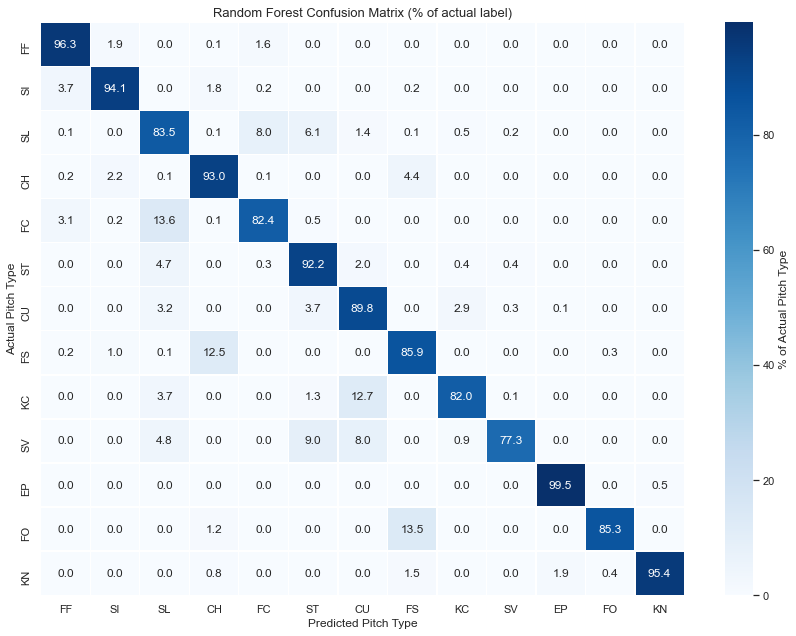

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=label_order)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    cm_pct,
    annot=True, fmt='.1f', cmap='Blues',
    xticklabels=label_order, yticklabels=label_order,
    linewidths=0.4, ax=ax,
    cbar_kws={'label': '% of Actual Pitch Type'}
)
ax.set_title('Random Forest Confusion Matrix (% of actual label)', fontsize=13)
ax.set_xlabel('Predicted Pitch Type')
ax.set_ylabel('Actual Pitch Type')
plt.tight_layout()
plt.show()

## 10. Most Common Misclassifications
Summarize the largest off-diagonal confusion pairs. These errors are useful because they identify pitch labels with similar physical signatures.

,actual,predicted,count,pct_of_actual,actual_name,predicted_name,pair
14,SL,FC,5160,8.041,Slider,Cutter,SL -> FC
30,FC,SL,4594,13.610,Cutter,Slider,FC -> SL
15,SL,ST,3890,6.062,Slider,Sweeper,SL -> ST
0,FF,SI,2577,1.886,Four-Seam Fastball,Sinker,FF -> SI
5,SI,FF,2475,3.715,Sinker,Four-Seam Fastball,SI -> FF
3,FF,FC,2231,1.633,Four-Seam Fastball,Cutter,FF -> FC
25,CH,FS,1973,4.416,Changeup,Split-Finger,CH -> FS
57,FS,CH,1536,12.454,Split-Finger,Changeup,FS -> CH
38,ST,SL,1410,4.696,Sweeper,Slider,ST -> SL
7,SI,CH,1196,1.795,Sinker,Changeup,SI -> CH


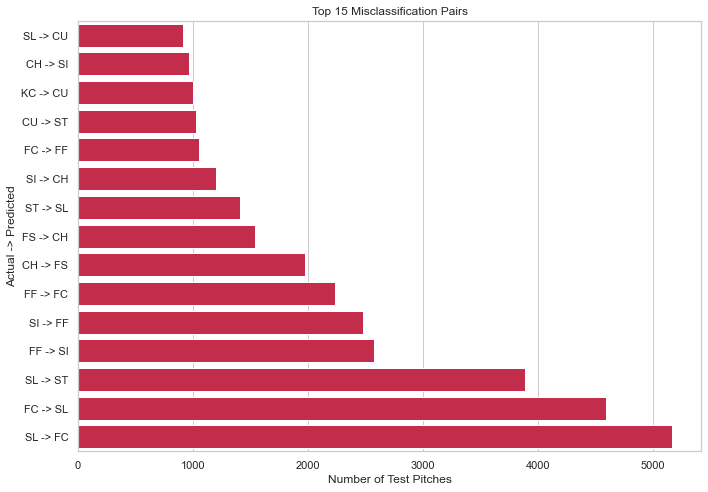

In [10]:
cm_counts = pd.DataFrame(cm, index=label_order, columns=label_order)

errors = []
for actual in label_order:
    for predicted in label_order:
        count = cm_counts.loc[actual, predicted]
        if actual != predicted and count > 0:
            errors.append({
                'actual': actual,
                'predicted': predicted,
                'count': int(count),
                'pct_of_actual': count / cm_counts.loc[actual].sum() * 100
            })

error_df = pd.DataFrame(errors).sort_values('count', ascending=False)
error_df['actual_name'] = error_df['actual'].map(PITCH_TYPE_MAP)
error_df['predicted_name'] = error_df['predicted'].map(PITCH_TYPE_MAP)
error_df['pair'] = error_df['actual'] + ' -> ' + error_df['predicted']

display(error_df.head(15))

top_errors = error_df.head(15).sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top_errors, x='count', y='pair', color='crimson', ax=ax)
ax.set_title('Top 15 Misclassification Pairs')
ax.set_xlabel('Number of Test Pitches')
ax.set_ylabel('Actual -> Predicted')
plt.tight_layout()
plt.show()

## 11. Feature Importance
Random Forest impurity-based importance shows which features the trees used most often to separate pitch labels. This is model-specific, but it is a good first check against baseball intuition.

,feature,importance
2,release_spin_rate,0.155
3,spin_axis,0.089
5,pfx_z,0.073
17,az,0.072
8,release_pos_x,0.070
13,vy0,0.070
4,pfx_x,0.067
15,ax,0.066
0,release_speed,0.065
10,release_pos_z,0.060


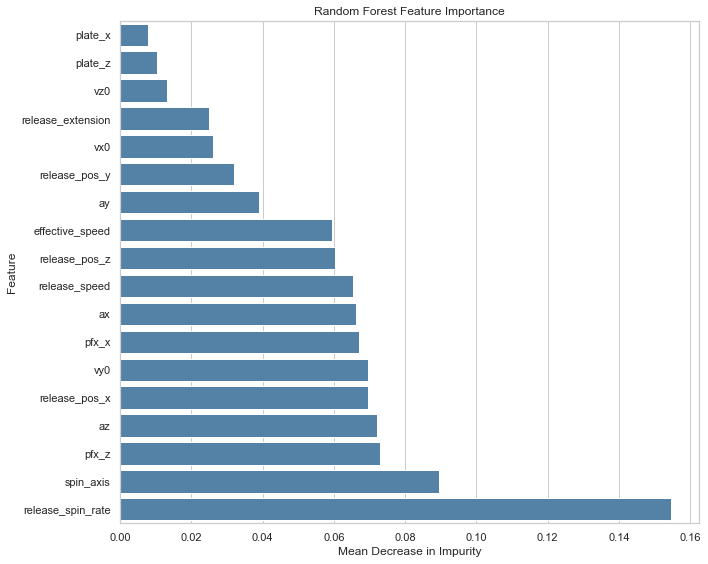

In [11]:
feature_importance = pd.DataFrame({
    'feature': BALL_FLIGHT_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=feature_importance.sort_values('importance', ascending=True),
    x='importance', y='feature', color='steelblue', ax=ax
)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 12. Permutation Importance
Permutation importance measures performance loss when each feature is shuffled. This provides a model-agnostic check and helps guard against over-interpreting impurity-based importance.

Running permutation importance on 7,500 held-out pitches...


,feature,importance_mean,importance_std
2,release_spin_rate,0.242,0.007
3,spin_axis,0.147,0.017
8,release_pos_x,0.128,0.013
10,release_pos_z,0.101,0.002
5,pfx_z,0.071,0.006
17,az,0.068,0.004
13,vy0,0.053,0.001
4,pfx_x,0.050,0.000
15,ax,0.043,0.001
9,release_pos_y,0.040,0.005


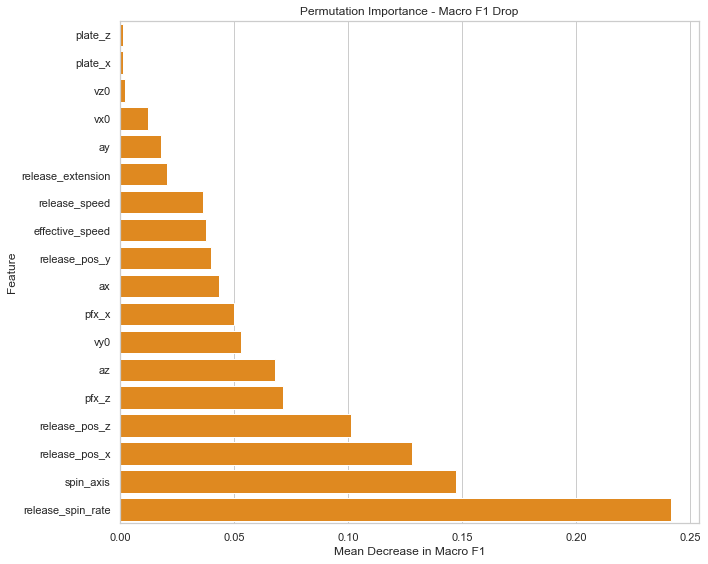

In [12]:
PERM_SAMPLE_SIZE = min(7500, len(X_test))
X_perm = X_test.sample(n=PERM_SAMPLE_SIZE, random_state=SEED)
y_perm = y_test.loc[X_perm.index]

print(f"Running permutation importance on {PERM_SAMPLE_SIZE:,} held-out pitches...")
perm = permutation_importance(
    rf,
    X_perm,
    y_perm,
    n_repeats=2,
    random_state=SEED,
    scoring='f1_macro',
    n_jobs=1
)

perm_importance = pd.DataFrame({
    'feature': BALL_FLIGHT_FEATURES,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_importance)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=perm_importance.sort_values('importance_mean', ascending=True),
    x='importance_mean', y='feature', color='darkorange', ax=ax
)
ax.set_title('Permutation Importance - Macro F1 Drop')
ax.set_xlabel('Mean Decrease in Macro F1')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 13. Evaluation by Pitcher Handedness
Because horizontal movement mirrors across pitcher handedness, check whether the model recreates labels equally well for RHP and LHP pitches.

,test_pitches,accuracy,balanced_accuracy,macro_f1
p_throws,,,,
L,114841,0.930,0.892,0.897
R,312020,0.906,0.881,0.877


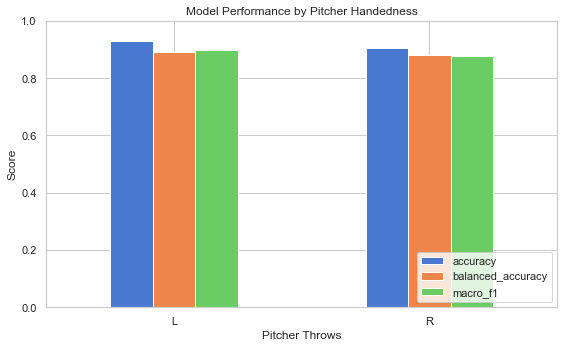

In [13]:
test_meta = df.loc[X_test.index, ['p_throws', 'season']].copy()
eval_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'p_throws': test_meta['p_throws'].values,
    'season': test_meta['season'].values
})

handedness_rows = []
for hand, group in eval_df.groupby('p_throws'):
    handedness_rows.append({
        'p_throws': hand,
        'test_pitches': len(group),
        'accuracy': accuracy_score(group['actual'], group['predicted']),
        'balanced_accuracy': balanced_accuracy_score(group['actual'], group['predicted']),
        'macro_f1': f1_score(group['actual'], group['predicted'], average='macro')
    })

handedness_eval = pd.DataFrame(handedness_rows).set_index('p_throws')
display(handedness_eval)

fig, ax = plt.subplots(figsize=(8, 5))
handedness_eval[['accuracy', 'balanced_accuracy', 'macro_f1']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance by Pitcher Handedness')
ax.set_xlabel('Pitcher Throws')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Evaluation by Season
The model is trained on the combined 2023-2025 dataset. Checking held-out performance by season helps identify whether label reconstruction is stable across years.

,test_pitches,accuracy,balanced_accuracy,macro_f1
season,,,,
2023,141860,0.906,0.877,0.871
2024,143680,0.916,0.899,0.881
2025,141321,0.915,0.886,0.885


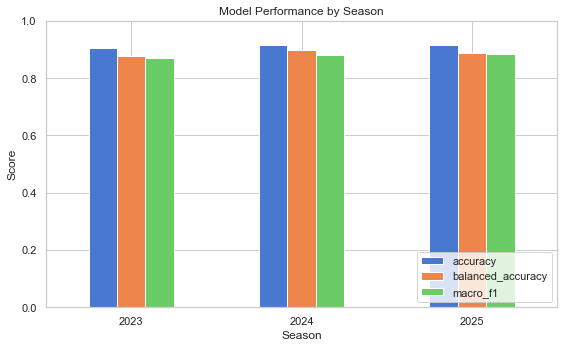

In [14]:
season_rows = []
for season, group in eval_df.groupby('season'):
    season_rows.append({
        'season': season,
        'test_pitches': len(group),
        'accuracy': accuracy_score(group['actual'], group['predicted']),
        'balanced_accuracy': balanced_accuracy_score(group['actual'], group['predicted']),
        'macro_f1': f1_score(group['actual'], group['predicted'], average='macro')
    })

season_eval = pd.DataFrame(season_rows).set_index('season').sort_index()
display(season_eval)

fig, ax = plt.subplots(figsize=(8, 5))
season_eval[['accuracy', 'balanced_accuracy', 'macro_f1']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Prediction Confidence
Use predicted probabilities to see whether the model is most accurate when it is most confident. Low-confidence predictions often correspond to borderline pitch labels.

,confidence_bin,pitches,accuracy,mean_confidence
0,"(0.2, 0.3]",194,0.351,0.279
1,"(0.3, 0.4]",2498,0.438,0.365
2,"(0.4, 0.5]",10727,0.539,0.462
3,"(0.5, 0.6]",30672,0.628,0.550
4,"(0.6, 0.7]",35090,0.763,0.652
5,"(0.7, 0.8]",46548,0.874,0.753
6,"(0.8, 0.9]",70317,0.946,0.854
7,"(0.9, 1.0]",230815,0.993,0.971


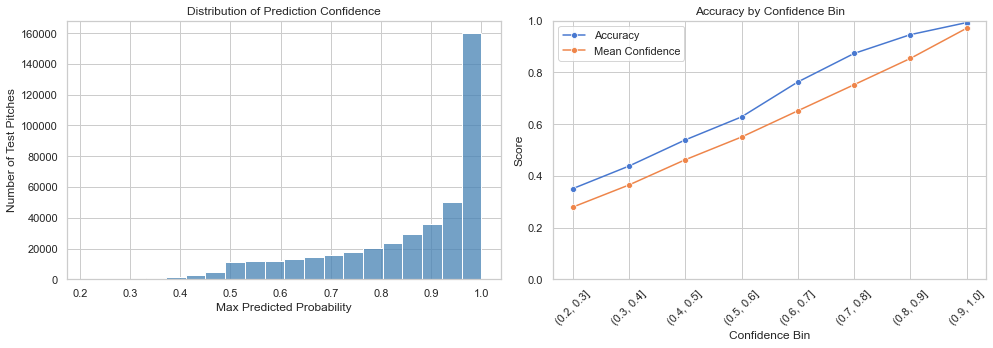

In [15]:
proba = rf.predict_proba(X_test)
confidence = proba.max(axis=1)

confidence_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'confidence': confidence
})
confidence_df['correct'] = confidence_df['actual'] == confidence_df['predicted']
confidence_df['confidence_bin'] = pd.cut(
    confidence_df['confidence'],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

confidence_summary = (
    confidence_df
    .groupby('confidence_bin', observed=True)
    .agg(
        pitches=('correct', 'size'),
        accuracy=('correct', 'mean'),
        mean_confidence=('confidence', 'mean')
    )
    .reset_index()
)

display(confidence_summary)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(confidence_df['confidence'], bins=20, color='steelblue', ax=ax1)
ax1.set_title('Distribution of Prediction Confidence')
ax1.set_xlabel('Max Predicted Probability')
ax1.set_ylabel('Number of Test Pitches')

plot_summary = confidence_summary.copy()
plot_summary['bin_label'] = plot_summary['confidence_bin'].astype(str)
sns.lineplot(data=plot_summary, x='bin_label', y='accuracy', marker='o', ax=ax2, label='Accuracy')
sns.lineplot(data=plot_summary, x='bin_label', y='mean_confidence', marker='o', ax=ax2, label='Mean Confidence')
ax2.set_title('Accuracy by Confidence Bin')
ax2.set_xlabel('Confidence Bin')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

## 16. Takeaways
This notebook treats the official MLB pitch labels as the target rather than as validation metadata. After running the model, the key interpretation questions are:

- Which official pitch labels are nearly deterministic from ball-flight features?
- Which pitch pairs are most frequently confused?
- Do velocity, movement, spin, and release-point importances align with baseball intuition?
- Does label reconstruction quality differ between RHP and LHP pitches?
- Is model performance stable across the 2023, 2024, and 2025 seasons?